### Creating a chatbot with multiple tools
* using arxiv (for research paper)
* wikipedia
*  self made functions like add or multiply stuffs  
LLM will decide which tool to call or if there is no need for tool call it will give the response.
langchain provides lot's of built-in tools for the  plugins 

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.invoke("attention is all you need")

arxiv


In [6]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.invoke("who is shantanu")

"Page: Shantanu\nSummary: Shantanu (Sanskrit: शांतनु, शान्तनु, IAST: Śāṃtanu, Śāntanu) is a character in the ancient Hindu epic Mahabharata. He was the King of Kuru Kingdom with his capital at Hastinapura. He was a descendant of the Bharata race, a forebear of the lineage of the Chandravamsha, the father of Bhishma and the great-grandfather of the Pandavas and the Kauravas.  \nShantanu was the youngest son of King Pratipa of Hastinapura and had been born during the king's later years. His eldest brother, Devapi, had leprosy, and had given up his rightful claim before becoming a hermit. The middle son, Bahlika (or Vahlika), abandoned his birth kingdom, and had started living with his maternal uncle in Balkh, subsequently inheriting his kingdom. Shantanu, thus, ascended the throne of Hastinapura.\n\nPage: Shantanu Maheshwari\nSummary: Shantanu Maheshwari (born 7 March 1991) is an Indian actor, dancer, and choreographer. He gained fame for his debut role as Swayam Shekhawat in the popular

In [11]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['TAVILY_API_KEY']=os.getenv("TAVILY_API_KEY")
os.environ['GROQ_API_KEY']=os.getenv("GROQ_API_KEY")

In [12]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/var/folders/h7/pr3ghf197n16xjyxbrzmfrqr0000gn/T/ipykernel_29591/3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [13]:
tavily.invoke("latest news in india")

[{'title': 'India news - breaking news, video and headlines and opinion - CNN',
  'url': 'https://www.cnn.com/world/india',
  'content': 'Workers stitch dupattas, a traditional scarf of ladies suits, at a garment factory in Amritsar on July 4, 2025. Indian exporters are anxiously eyeing the possible reintroduction of Donald Trump\'s punishing tariffs next week, though many hold out hope for a last-minute reprieve. New Delhi and Washington have been locked in multiple rounds of talks, with hopes for an interim pact to avert the 26 percent "reciprocal" tolls meted out to India. (Photo by Narinder NANU / AFP) (Photo by NARINDER [...] ### CNN values your feedback\n\n# India\n\n## Latest news [...] People watch a laser show on the banks of the river Sarayu during Deepotsav celebrations on the eve of the Hindu festival of Diwali in Ayodhya on November 3, 2021. (Photo by SANJAY KANOJIA / AFP) (Photo by SANJAY KANOJIA/AFP via Getty Images)\nA rendering of the proposed Navi Airport, Mumbai.\nUS

In [14]:
#combining the tools 
tools=[arxiv,wiki,tavily]
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")
llm_with_tools=llm.bind_tools(tools)



In [15]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"what is the recent india news")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news about India. Let me see which tool I should use here. The available tools are arxiv, wikipedia, and tavily_search_results_json.\n\nArxiv is for scientific articles, so that\'s not suitable here. Wikipedia provides general information but might not have the latest news. The user wants recent news, which would be covered by current events. The tavily_search_results_json is described as a search engine optimized for current events. That seems like the right choice. So I\'ll use that tool with the query "recent India news".\n', 'tool_calls': [{'id': 'x0t94jfp0', 'function': {'arguments': '{"query":"recent India news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 146, 'prompt_tokens': 399, 'total_tokens': 545, 'completion_time': 0.348666602, 'prompt_time': 0.01734998, 'queue_time': 0.05049826, 'total_time': 0.36601

In [16]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

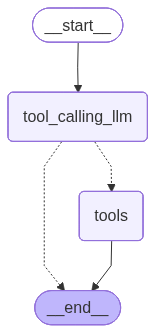

In [17]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (gq749gxbe)
 Call ID: gq749gxbe
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, based
solely on attention mechanisms, dispensing with recurrence and convolutions
entirely. Experiments on two machine translation tasks show these models